/tmp/ipykernel_2229581/1043724347.py:80: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  fig.colorbar(ss,fraction=0.05)


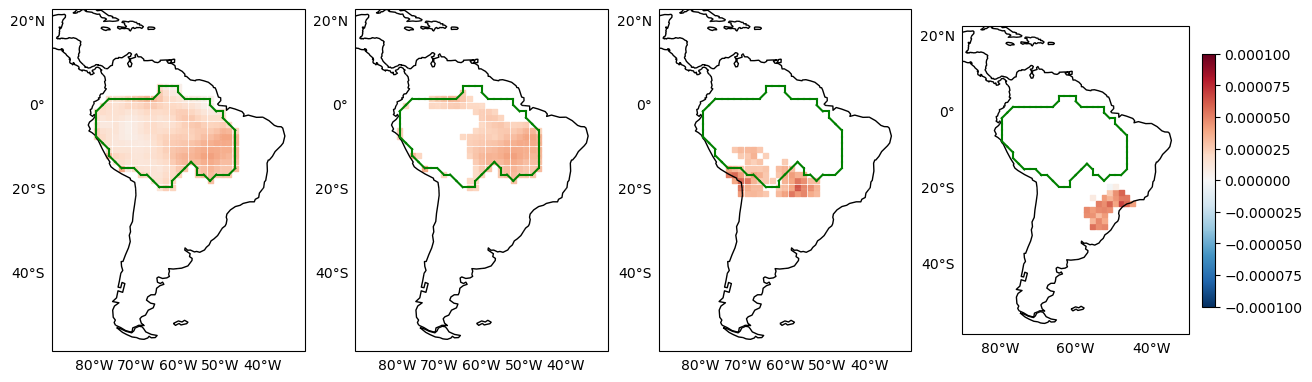

In [19]:
from matplotlib.colors import CenteredNorm,TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon
import cartopy.io.shapereader as shpreader
import pandas as pd
import numpy as np


fig, axis = plt.subplots(1, 4, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(15,5))
for p in range(4):
    axis[p].coastlines()  # cartopy function
    gl = axis[p].gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
    gl.top_labels=False                                 
    gl.right_labels=False
    axis[p].set_extent([-90, -30, -55, 20])
    norm=TwoSlopeNorm(vmin=-0.0001,vcenter=0., vmax=0.0001) 
    polygon=np.load('amazon_boundary.npy',)
    for i in range(len(polygon)-1):
        axis[p].plot([polygon[i][0],polygon[i+1][0]],[polygon[i][1],polygon[i+1][1]],c='g')




#lai anormaly inout flattern to one-dimension (733,1,216,21,21)
eg_all=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/A-69822648.csv')
threshold_amazon_find_a=0.00002
threshold_a_find_b=0.000023

#####1. amazon->upwind#########
Amazon_info=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/Amazon_info.csv")
ed_Amazon_as_donator=eg_all.merge(Amazon_info,on=['month','xlats','ylons','lat_center','lon_center'])
aa=ed_Amazon_as_donator.groupby(['xlats','ylons']).mean().reset_index()
ss=axis[0].scatter(x=aa.xlats,y=aa.ylons,c=aa.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
#####amazon->upwind#########

# ###############2. test threshod:amazon ->a ################
amazon_a=aa.copy()
amazon_a[abs(amazon_a.eg_upwind_new)<threshold_amazon_find_a]=np.nan
amazon_a=amazon_a.dropna(axis=0)
# amazon_a=amazon_a[(amazon_a.ylons>-8)&(amazon_a.xlats<-50)]
ss=axis[1].scatter(x=amazon_a.xlats,y=amazon_a.ylons,c=amazon_a.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
# ###############################

###############3. test threshod：a->b ################
a_info=amazon_a[['xlats','ylons']]
ed_a_as_donator=eg_all.merge(a_info,on=['xlats','ylons'])
ab=ed_a_as_donator.groupby(['lat_center','lon_center']).mean().reset_index()
ab[abs(ab.eg_upwind_new)<threshold_a_find_b]=np.nan
ab=ab.dropna(axis=0)
ab=ab[(ab.lon_center<-52)&(ab.lat_center<-10)&(ab.lon_center>-75)&(ab.lat_center>-22)]
ss=axis[2].scatter(x=ab.lon_center,y=ab.lat_center,c=ab.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
##############################



# #########4. test threshod:b->c######################
c_info=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/agr_lla1.csv')
lon_center_ab = ab['lon_center']
lat_center_ab = ab['lat_center']
results = []
for lat, lon in zip(lat_center_ab, lon_center_ab):
    filtered = eg_all[(eg_all['ylons'] == lat) & (eg_all['xlats'] == lon)]
    results.append(filtered)
b_upwind = pd.concat(results)
#-----------
lon_center_c=c_info['lon']
lat_center_c=c_info['lat']
results = []
for lat, lon in zip(lat_center_c, lon_center_c):
    filtered = b_upwind[(b_upwind['lat_center'] == lat) & (b_upwind['lon_center'] == lon)]
    results.append(filtered)
bc = pd.concat(results)
bc_mean=bc.groupby(['lat_center','lon_center']).mean().reset_index()
axis[3].scatter(x=bc_mean.lon_center,y=bc_mean.lat_center,c=bc_mean.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')


fig.colorbar(ss,fraction=0.05)

In [20]:
a_info['lat']=a_info['ylons']
a_info['lon']=a_info['xlats']
a_info.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_a_lats_lons-2-esa-maxmin.npy')

b_info=pd.DataFrame()
b_info['lat']=ab['lat_center']
b_info['lon']=ab['lon_center']
b_info.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_b_lats_lons-2-esa-maxmin.npy')

# c_info[['lat','lon']].to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/BAZ_info.npy')

/tmp/ipykernel_2229581/3047652731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_info['lat']=a_info['ylons']
/tmp/ipykernel_2229581/3047652731.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_info['lon']=a_info['xlats']


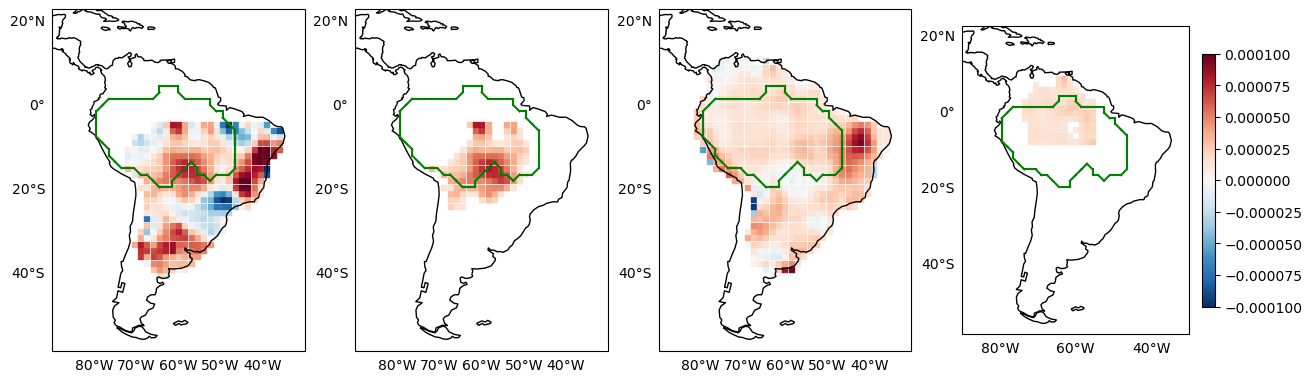

In [22]:
from matplotlib.colors import CenteredNorm,TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon
import cartopy.io.shapereader as shpreader
import pandas as pd
import numpy as np


fig, axis = plt.subplots(1, 4, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(15,5))
for p in range(4):
    axis[p].coastlines()  # cartopy function
    gl = axis[p].gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
    gl.top_labels=False                                 
    gl.right_labels=False
    axis[p].set_extent([-90, -30, -55, 20])
    norm=TwoSlopeNorm(vmin=-0.0001,vcenter=0., vmax=0.0001) 
    polygon=np.load('amazon_boundary.npy',)
    for i in range(len(polygon)-1):
        axis[p].plot([polygon[i][0],polygon[i+1][0]],[polygon[i][1],polygon[i+1][1]],c='g')


eg_all=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/A-69822648-2-esa-maxmin.csv')
if 'eg_upwind_new' not in eg_all.columns.tolist():
    eg_all['eg_upwind_new']=-eg_all['eg_upwind']
threshold_c_find_b=0.00001
threshold_b_find_a=0.00001


#####1. baz->upwind#########
c_info=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/BAZ_info.npy')
lon_center_c=c_info['lon']
lat_center_c=c_info['lat']
results = []
for lat, lon in zip(lat_center_c, lon_center_c):
    filtered = eg_all[(eg_all['lat_center'] == lat) & (eg_all['lon_center'] == lon)]
    results.append(filtered)
c_upwind = pd.concat(results)
c_upwind_mean=c_upwind.groupby(['xlats','ylons']).mean().reset_index()
ss=axis[0].scatter(x=c_upwind_mean.xlats,y=c_upwind_mean.ylons,c=c_upwind_mean.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
#####baz->upwind#########

# # ###############2. test threshod:baz's upwind -> b ################
cb=c_upwind_mean.copy()
cb[cb.eg_upwind_new<threshold_c_find_b]=np.nan
cb=cb.dropna(axis=0)
cb=cb[(cb.ylons>-25)&(cb.xlats<-48)]
ss=axis[1].scatter(x=cb.xlats,y=cb.ylons,c=cb.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
# # #############################

# ###############3. test threshod：b->a ################
b_info=cb[['xlats','ylons']]
lon_center_b=b_info['xlats']
lat_center_b=b_info['ylons']
results = []
for lat, lon in zip(lat_center_b, lon_center_b):
    filtered = eg_all[(eg_all['lat_center'] == lat) & (eg_all['lon_center'] == lon)]
    results.append(filtered)
b_upwind = pd.concat(results)
b_upwind_mean=b_upwind.groupby(['xlats','ylons']).mean().reset_index()
ss=axis[2].scatter(x=b_upwind_mean.xlats,y=b_upwind_mean.ylons,c=b_upwind_mean.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
# ##########################


# # #########4. test threshod: b->a######################
ba=b_upwind_mean.copy()
ba[ba.eg_upwind_new<threshold_b_find_a]=np.nan
ba=ba.dropna(axis=0)
ba=ba[(ba.xlats<-55)&(ba.xlats>-75)&(ba.ylons>-8)]#
ss=axis[3].scatter(x=ba.xlats,y=ba.ylons,c=ba.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
fig.colorbar(ss,fraction=0.05)

In [23]:
a_info=pd.DataFrame()
a_info['lat']=ba['ylons']
a_info['lon']=ba['xlats']
a_info.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_a_lats_lons-2-esa-maxmin.npy')


b_info['lat']=b_info['ylons']
b_info['lon']=b_info['xlats']
b_info.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_b_lats_lons-2-esa-maxmin.npy')

# c_info[['lat','lon']].to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_c_lats_lons_mean.npy')

/tmp/ipykernel_2229581/387968085.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b_info['lat']=b_info['ylons']
/tmp/ipykernel_2229581/387968085.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b_info['lon']=b_info['xlats']


In [2]:
def get_intersection_lat_lon(zone1,zone2):
    df1 = zone1.drop_duplicates()
    df2 = zone2.drop_duplicates()
    common_rows = df1.merge(df2, on=['lat','lon'], how='inner')[['lat','lon']]
    return common_rows
    
a_info0=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_a_lats_lons-2-esa-maxmin.npy')
a_info1=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_a_lats_lons-2-esa-maxmin.npy')
a_info2=get_intersection_lat_lon(a_info0,a_info1)
a_info2.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/intersection_a_lats_lons-2-esa-maxmin.npy')

b_info0=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_b_lats_lons-2-esa-maxmin.npy')
b_info1=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_b_lats_lons-2-esa-maxmin.npy')
b_info2=get_intersection_lat_lon(b_info0,b_info1)
b_info2.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/intersection_b_lats_lons-2-esa-maxmin.npy')


In [66]:

a_info0=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_a_lats_lons-2-maxmin.npy')
a_info1=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_a_lats_lons-2-maxmin.npy')
###
a_info1=a_info1[:-3]
a_info1.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_a_lats_lons-2-maxminx.npy')
###
a_info2=get_intersection_lat_lon(a_info0,a_info1)
a_info2.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/intersection_a_lats_lons-2-maxmin.npy')

b_info0=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_b_lats_lons-2-maxmin.npy')
###
llb_traceback=pd.DataFrame()
for i in range(1,11):
    if i <7:
        llb_traceback.loc[i-1,'lat']=-1.5*i-6
        llb_traceback.loc[i-1,'lon']=-69+4.5
    elif (i>6) and (i<9):
        llb_traceback.loc[i-1,'lon']=-69+3
        llb_traceback.loc[i-1,'lat']=-1.5*(i-6)-9
    else:
        llb_traceback.loc[i-1,'lon']=-69+3
        llb_traceback.loc[i-1,'lat']=1.5*(i-8)-9
b_info0_new=pd.concat((b_info0,llb_traceback),axis=0,ignore_index=True)
b_info0_new=b_info0_new.dropna(subset=['lat', 'lon'], how='all').drop_duplicates(subset=['lat', 'lon'])
b_info0_new.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_b_lats_lons-2-maxminx.npy')
####

b_info1=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_b_lats_lons-2-maxmin.npy')
b_info2=get_intersection_lat_lon(b_info0,b_info1)
b_info2.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/intersection_b_lats_lons-2-maxmin.npy')


In [77]:
traceback_a_lats_lons=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/Agr_c_FV.csv")
traceforward_a_lats_lons=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/Amazon_A_FV.csv")
traceback_a_lats_lons=traceback_a_lats_lons[['lat','lon']].drop_duplicates()
traceback_a_lats_lons.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_a_lats_lons.npy')
traceforward_a_lats_lons=traceforward_a_lats_lons[['lat','lon']].drop_duplicates()
traceforward_a_lats_lons.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_a_lats_lons.npy')


traceforward_b=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/Agr_b_FV2.csv")
traceback_b=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/Amazon_B_FV.csv")
traceback_b=traceback_b[['lat','lon']].drop_duplicates()
traceback_b.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_b_lats_lons.npy')
traceforward_b=traceforward_b[['lat','lon']].drop_duplicates()
traceforward_b.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_b_lats_lons.npy')


In [79]:
a_info0=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_a_lats_lons.npy')
a_info1=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_a_lats_lons.npy')
a_info2=get_intersection_lat_lon(a_info0,a_info1)
a_info2.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/intersection_a_lats_lons.npy')

b_info0=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceback_b_lats_lons.npy')
b_info1=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/traceforward_b_lats_lons.npy')
b_info2=get_intersection_lat_lon(b_info0,b_info1)
b_info2.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/intersection_b_lats_lons.npy')


In [ ]:
=============================================

/tmp/ipykernel_144294/580910053.py:80: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  fig.colorbar(ss,fraction=0.05)


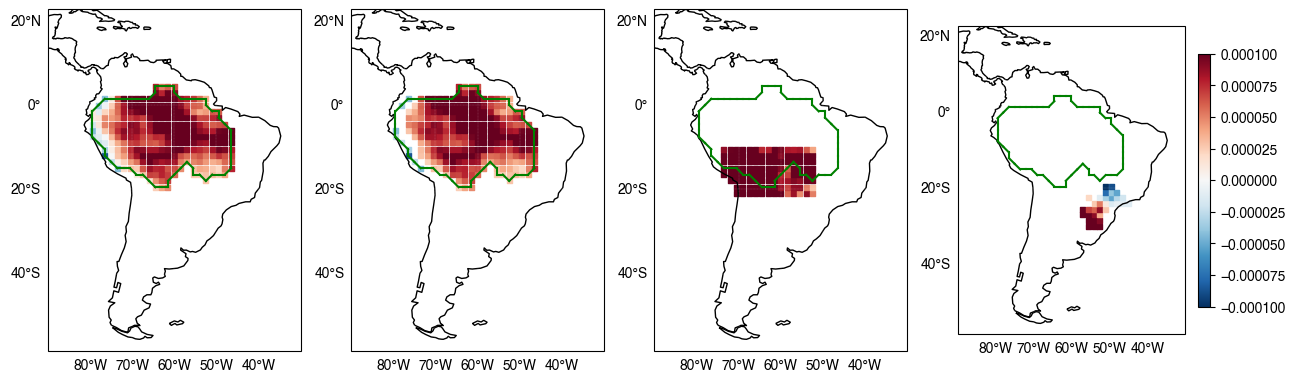

In [2]:
from matplotlib.colors import CenteredNorm,TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon
import cartopy.io.shapereader as shpreader
import pandas as pd
import numpy as np


fig, axis = plt.subplots(1, 4, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(15,5))
for p in range(4):
    axis[p].coastlines()  # cartopy function
    gl = axis[p].gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
    gl.top_labels=False                                 
    gl.right_labels=False
    axis[p].set_extent([-90, -30, -55, 20])
    norm=TwoSlopeNorm(vmin=-0.0001,vcenter=0., vmax=0.0001) 
    polygon=np.load('amazon_boundary.npy',)
    for i in range(len(polygon)-1):
        axis[p].plot([polygon[i][0],polygon[i+1][0]],[polygon[i][1],polygon[i+1][1]],c='g')




#用somo的eg
eg_all=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/69822648.csv')
if 'eg_upwind_new' not in eg_all.columns.tolist():
    eg_all['eg_upwind_new']=eg_all['eg_upwind']
threshold_amazon_find_a=0.00002
threshold_a_find_b=0.000023

#####1. amazon->upwind#########
Amazon_info=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/Amazon_info.csv")
ed_Amazon_as_donator=eg_all.merge(Amazon_info,on=['month','xlats','ylons','lat_center','lon_center'])
aa=ed_Amazon_as_donator.groupby(['xlats','ylons']).mean().reset_index()
ss=axis[0].scatter(x=aa.xlats,y=aa.ylons,c=aa.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
#####amazon->upwind#########

# ###############2. test threshod:amazon 找a ################
amazon_a=aa.copy()
amazon_a[abs(amazon_a.eg_upwind_new)<threshold_amazon_find_a]=np.nan
amazon_a=amazon_a.dropna(axis=0)
# amazon_a=amazon_a[(amazon_a.ylons>-8)&(amazon_a.xlats<-50)]
ss=axis[1].scatter(x=amazon_a.xlats,y=amazon_a.ylons,c=amazon_a.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
# ###############测试阈值################

###############3. test threshod：a找b ################
a_info=amazon_a[['xlats','ylons']]
ed_a_as_donator=eg_all.merge(a_info,on=['xlats','ylons'])
ab=ed_a_as_donator.groupby(['lat_center','lon_center']).mean().reset_index()
ab[abs(ab.eg_upwind_new)<threshold_a_find_b]=np.nan
ab=ab.dropna(axis=0)
ab=ab[(ab.lon_center<-52)&(ab.lat_center<-10)&(ab.lon_center>-75)&(ab.lat_center>-22)]
ss=axis[2].scatter(x=ab.lon_center,y=ab.lat_center,c=ab.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
#############################



# #########4. test threshod:b->c######################
c_info=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/agr_lla1.csv')
lon_center_ab = ab['lon_center']
lat_center_ab = ab['lat_center']
results = []
for lat, lon in zip(lat_center_ab, lon_center_ab):
    filtered = eg_all[(eg_all['ylons'] == lat) & (eg_all['xlats'] == lon)]
    results.append(filtered)
b_upwind = pd.concat(results)
#-----------
lon_center_c=c_info['lon']
lat_center_c=c_info['lat']
results = []
for lat, lon in zip(lat_center_c, lon_center_c):
    filtered = b_upwind[(b_upwind['lat_center'] == lat) & (b_upwind['lon_center'] == lon)]
    results.append(filtered)
bc = pd.concat(results)
bc_mean=bc.groupby(['lat_center','lon_center']).mean().reset_index()
axis[3].scatter(x=bc_mean.lon_center,y=bc_mean.lat_center,c=bc_mean.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')


fig.colorbar(ss,fraction=0.05)

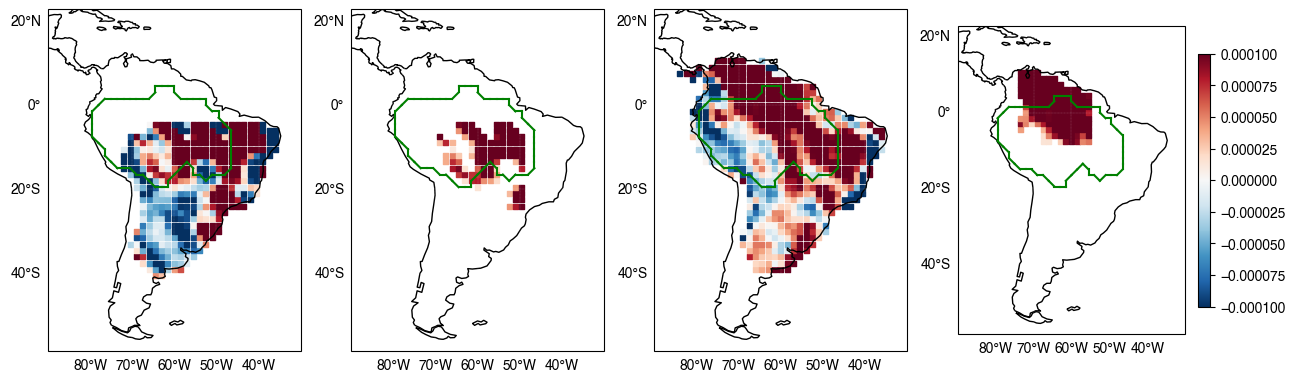

In [3]:
from matplotlib.colors import CenteredNorm,TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon
import cartopy.io.shapereader as shpreader
import pandas as pd
import numpy as np


fig, axis = plt.subplots(1, 4, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(15,5))
for p in range(4):
    axis[p].coastlines()  # cartopy function
    gl = axis[p].gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
    gl.top_labels=False                                 
    gl.right_labels=False
    axis[p].set_extent([-90, -30, -55, 20])
    norm=TwoSlopeNorm(vmin=-0.0001,vcenter=0., vmax=0.0001) 
    polygon=np.load('amazon_boundary.npy',)
    for i in range(len(polygon)-1):
        axis[p].plot([polygon[i][0],polygon[i+1][0]],[polygon[i][1],polygon[i+1][1]],c='g')


eg_all=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/69822648.csv')
if 'eg_upwind_new' not in eg_all.columns.tolist():
    eg_all['eg_upwind_new']=eg_all['eg_upwind']
threshold_c_find_b=0.00001
threshold_b_find_a=0.00001


#####1. baz->upwind#########
c_info=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540_541_548/BAZ_info.npy')
lon_center_c=c_info['lon']
lat_center_c=c_info['lat']
results = []
for lat, lon in zip(lat_center_c, lon_center_c):
    filtered = eg_all[(eg_all['lat_center'] == lat) & (eg_all['lon_center'] == lon)]
    results.append(filtered)
c_upwind = pd.concat(results)
c_upwind_mean=c_upwind.groupby(['xlats','ylons']).mean().reset_index()
ss=axis[0].scatter(x=c_upwind_mean.xlats,y=c_upwind_mean.ylons,c=c_upwind_mean.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
#####baz->upwind#########

# # ###############2. test threshod:baz's upwind 找b ################
cb=c_upwind_mean.copy()
cb[cb.eg_upwind_new<threshold_c_find_b]=np.nan
cb=cb.dropna(axis=0)
cb=cb[(cb.ylons>-25)&(cb.xlats<-48)]
ss=axis[1].scatter(x=cb.xlats,y=cb.ylons,c=cb.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
# # ###############测试阈值################

# ###############3. test threshod：b找a ################
b_info=cb[['xlats','ylons']]
lon_center_b=b_info['xlats']
lat_center_b=b_info['ylons']
results = []
for lat, lon in zip(lat_center_b, lon_center_b):
    filtered = eg_all[(eg_all['lat_center'] == lat) & (eg_all['lon_center'] == lon)]
    results.append(filtered)
b_upwind = pd.concat(results)
b_upwind_mean=b_upwind.groupby(['xlats','ylons']).mean().reset_index()
ss=axis[2].scatter(x=b_upwind_mean.xlats,y=b_upwind_mean.ylons,c=b_upwind_mean.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
# ############################


# # #########4. b->a######################
ba=b_upwind_mean.copy()
ba[ba.eg_upwind_new<threshold_b_find_a]=np.nan
ba=ba.dropna(axis=0)
ba=ba[(ba.xlats<-55)&(ba.xlats>-75)&(ba.ylons>-8)]#
ss=axis[3].scatter(x=ba.xlats,y=ba.ylons,c=ba.eg_upwind_new,cmap='RdBu_r',s=13,norm=norm,marker='s')
fig.colorbar(ss,fraction=0.05)